# 03 — Baseline Modelling

**Competition:** A Cloned Airbnb Booking Prediction Competition — K353  
**Course:** COMP 468 — Abdullah Gül University

## Goal
Build a clean, **leakage-proof** baseline pipeline using course-allowed models:
1. `LinearRegression` (Section IV.B.1 baseline)
2. `DecisionTreeRegressor` (Modules 2-3)
3. `RandomForestRegressor` (Module 5)
4. `GradientBoostingRegressor` (Module 9)

All steps live inside a `Pipeline` / `ColumnTransformer` so that imputation + encoding happen **inside each CV fold** — no data leakage.

Outputs:
- `outputs/oof_<model>.npy` — out-of-fold predictions per model (used later for ensembling/stacking).
- `outputs/submission_baseline_<model>.csv` — Kaggle submission file for each baseline.
- `outputs/baseline_cv_results.csv` — CV summary table.

---

### Outline
1. Setup
2. Load engineered features
3. Build preprocessing `ColumnTransformer`
4. 5-fold CV evaluation
   - 4.1 DecisionTree
   - 4.2 RandomForest
   - 4.3 GradientBoosting
5. Results summary
6. Refit best model on full train + generate Kaggle submission
7. Permutation feature importance (sanity peek)

## 1. Setup

In [ ]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('Outputs dir:', OUT_DIR.resolve())

Outputs dir: /Users/bashkal/Desktop/Comp468-ML_in_Python/ali/ML-Final/outputs


## 2. Load Engineered Features

In [21]:
# Load the cleaned features we persisted in notebook 02
try:
    train_df = pd.read_parquet(OUT_DIR / 'train_features.parquet')
    test_df  = pd.read_parquet(OUT_DIR / 'test_features.parquet')
    print('Loaded parquet samples from', OUT_DIR.resolve())
except Exception as e:
    print('Parquet failed, trying CSV:', e)
    train_df = pd.read_csv(OUT_DIR / 'train_features.csv')
    test_df  = pd.read_csv(OUT_DIR / 'test_features.csv')
    print('Loaded CSV samples from', OUT_DIR.resolve())

print(f'Shapes: train {train_df.shape} | test {test_df.shape}')
train_df.head()

Loaded parquet samples from /Users/bashkal/Desktop/Comp468-ML_in_Python/ali/ML-Final/outputs
Shapes: train (24372, 149) | test (24318, 148)


,PropertyID,NumReserveDays2016Q3,PropertyType,ListingType,Zipcode,Neighborhood,MetropolitanStatisticalArea,NumberofReviews,OverallRating,Bedrooms,Bathrooms,MaxGuests,ResponseRate,ResponseTimemin,Superhost,CancellationPolicy,SecurityDeposit,CleaningFee,ExtraPeopleFee,PublishedNightlyRate,PublishedMonthlyRate,PublishedWeeklyRate,MinimumStay,NumberofPhotos,BusinessReady,InstantbookEnabled,Latitude,Longitude,PropertyAgeDays,ReviewsPerMonth,PricePerGuest,WeeklyDiscount,MonthlyDiscount,BedBathRatio,ResponseRate_missing,ResponseTimemin_missing,SecurityDeposit_missing,CleaningFee_missing,ExtraPeopleFee_missing,OverallRating_missing,...,q1_wd_booked,q1_wd_price_mean,q1_we_booking_rate,q1_wd_booking_rate,q1_weekend_premium,q1_weekend_minus_weekday_book_rate,q2_we_days,q2_we_booked,q2_we_price_mean,q2_wd_days,q2_wd_booked,q2_wd_price_mean,q2_we_booking_rate,q2_wd_booking_rate,q2_weekend_premium,q2_weekend_minus_weekday_book_rate,q1_booked_m1,q1_booked_m2,q1_booked_m3,q2_booked_m4,q2_booked_m5,q2_booked_m6,q1_status_changes,q1_new_bookings,q1_booking_ends,q2_status_changes,q2_new_bookings,q2_booking_ends,h1_status_changes,h1_new_bookings,h1_booking_ends,recent_days,recent_booked,recent_available,recent_price_mean,recent_price_std,recent_booking_rate,recent_available_rate,price_change_q2_q1,booking_rate_change_q2_q1
0,105,0,Apartment,Private room,10036,Hell's Kitchen,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",39.0,4.8,1.0,1.0,7,100.0,14.55,0.0,Flexible,NaN,NaN,150.0,549,15000.0,5000.0,1,25.0,0.0,0.0,40.762099,-73.996022,2925,0.400000,78.428571,-0.301067,0.089253,1.0,0,0,1,1,0,0,...,0,549.000000,0.000000,0.000000,1.425015,0.000000,39,0,782.333313,52,0,549.000000,0.000000,0.000000,1.425015,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30.0,0.0,30.0,642.333313,157.421753,0.0,1.000000,0.000000,0.000000
1,2534,0,Apartment,Entire home/apt,10065,Upper East Side,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",1.0,3.0,1.0,1.0,2,NaN,NaN,0.0,Moderate,500.0,25.0,NaN,145,4060.0,1015.0,3,16.0,0.0,0.0,40.762059,-73.961365,2855,0.010508,72.500000,0.000000,0.066667,1.0,1,1,0,0,1,0,...,0,156.057693,0.000000,0.000000,1.031013,0.000000,39,16,147.051285,52,24,147.307693,0.410256,0.461538,0.998259,-0.051282,0,0,0,1,9,30,0,0,0,7,1,1,7,1,1,30.0,30.0,0.0,145.000000,0.000000,1.0,0.000000,-0.069145,0.439560
2,2539,35,Apartment,Private room,11218,Kensington,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",3.0,5.0,1.0,1.0,5,100.0,1.98,0.0,Moderate,250.0,25.0,25.0,64,999.0,299.0,1,12.0,0.0,0.0,40.647486,-73.972370,2854,0.031535,12.800000,0.332589,0.479688,1.0,0,0,0,0,0,0,...,0,45.923077,0.000000,0.000000,1.474595,0.000000,39,0,72.333336,52,0,59.000000,0.000000,0.000000,1.225989,0.000000,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,30.0,0.0,30.0,64.333336,8.995529,0.0,1.000000,0.171008,0.000000
3,3330,43,Apartment,Private room,11206,Williamsburg,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",21.0,4.8,1.0,1.0,2,95.0,550.12,0.0,Strict,150.0,75.0,50.0,175,1900.0,650.0,3,32.0,0.0,0.0,40.708558,-73.942362,2792,0.225645,87.500000,0.469388,0.638095,1.0,0,0,0,0,0,0,...,0,85.384613,0.051282,0.000000,1.005405,0.051282,39,0,90.000000,52,0,90.192307,0.000000,0.000000,0.997868,0.000000,2,0,0,0,0,0,4,1,2,1,0,0,5,1,2,30.0,0.0,1.0,90.333336,1.825742,0.0,0.033333,0.052902,-0.021978
4,3831,76,Other,Entire home/apt,11238,Clinton Hill,"New York-Newark-Jersey City, NY-NJ-PA Metro Area",87.0,4.5,1.0,1.0,3,100.0,31.38,0.0,Moderate,500.0,NaN,NaN,89,2100.0,575.0,1,43.0,0.0,0.0,40.685138,-73.959757,2765,0.943942,29.666667,0.077047,0.213483,1.0,0,0,0,1,1,0,...,15,84.788460,0.282051,0.288462,0.998261,-0.006410,39,13,86.179489,52,12,86.461540,0.333333,0.230769,0.996738,0.102564,1,5,20,10,15,0,9,0,0,11,0,0,20,0,0,30.0,0.0,2.0,85.266670,1.014832,0.0,0.066667,0.019066,-0.010989


In [22]:

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [23]:
TARGET   = 'NumReserveDays2016Q3'
ID_COL   = 'PropertyID'
DROP_COLS = [ID_COL, TARGET]

y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=DROP_COLS)
X_test = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL].values

# Align columns (test should have identical columns to train X)
missing_in_test = [c for c in X.columns if c not in X_test.columns]
extra_in_test   = [c for c in X_test.columns if c not in X.columns]
print('Missing in test:', missing_in_test)
print('Extra   in test:', extra_in_test)
X_test = X_test.reindex(columns=X.columns)
print('After align — X:', X.shape, '| X_test:', X_test.shape)

Missing in test: []
Extra   in test: []
After align — X: (24372, 147) | X_test: (24318, 147)


In [24]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# Cap very-high-cardinality categoricals (e.g., Zipcode, Neighborhood) by
# keeping only the top-K most-frequent values for OneHot; rare values become 'Other'.
TOPK = 30
for c in cat_cols:
    top_values = X[c].value_counts(dropna=False).head(TOPK).index
    X[c]      = X[c].where(X[c].isin(top_values), other='Other')
    X_test[c] = X_test[c].where(X_test[c].isin(top_values), other='Other')

print(f'Numeric cols    : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}')
print('Categorical examples:', cat_cols[:10])

Numeric cols    : 141
Categorical cols: 6
Categorical examples: ['PropertyType', 'ListingType', 'Neighborhood', 'MetropolitanStatisticalArea', 'CancellationPolicy', 'geo_cluster']


## 3. Preprocessing `ColumnTransformer`
- **Numerics:** median imputation. Tree-based models don't need scaling.
- **Categoricals:** fill `NaN` with `'missing'`, then OneHotEncode (`handle_unknown='ignore'`).
- The whole thing lives in a Pipeline so that imputation is fit only on training folds (no leakage).

In [ ]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('Preprocessor ready.')

Preprocessor ready.


## 4. 5-Fold CV Evaluation

Helper that runs one model through CV and returns OOF predictions + mean MSE.

In [ ]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(name, model, X, y, kf=kf):
    pipe = Pipeline(steps=[
        ('prep',  preprocessor),
        ('model', model),
    ])
    t0 = time.time()
    fold_mses = []
    fold_maes = []
    fold_r2s  = []
    oof = np.zeros(len(y))
    
    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[va])
        pred = np.clip(pred, 0, 92)   # target is bounded in [0, 92]
        oof[va] = pred
        
        mse = mean_squared_error(y[va], pred)
        mae = mean_absolute_error(y[va], pred)
        r2  = r2_score(y[va], pred)
        
        fold_mses.append(mse)
        fold_maes.append(mae)
        fold_r2s.append(r2)
        print(f'  fold {fold+1}: MSE = {mse:.3f} | MAE = {mae:.3f} | R2 = {r2:.3f}')
        
    elapsed = time.time() - t0
    mean_mse = float(np.mean(fold_mses))
    mean_mae = float(np.mean(fold_maes))
    mean_r2  = float(np.mean(fold_r2s))
    
    print(f'\n{name:>22s} | MSE = {mean_mse:7.3f} | MAE = {mean_mae:7.3f} | R2 = {mean_r2:7.3f} | {elapsed:5.1f}s')
    np.save(OUT_DIR / f'oof_{name}.npy', oof)
    
    return {'name': name, 'mse_mean': mean_mse, 'mae_mean': mean_mae, 'r2_mean': mean_r2,
            'seconds': elapsed, 'oof': oof}

### 4.1 DecisionTreeRegressor

### 4.0 LinearRegression (Section IV.B Baseline)
The simplest model to check for linear relationships between features and the target count.


In [ ]:
lr_model = LinearRegression()
results.append(evaluate_model('LinearRegression', lr_model, X, y))


In [27]:
results = []

dt_model = DecisionTreeRegressor(max_depth=12, min_samples_leaf=20,
                                 random_state=RANDOM_STATE)
results.append(evaluate_model('DecisionTree', dt_model, X, y))

  fold 1: MSE = 237.402
  fold 2: MSE = 241.328
  fold 3: MSE = 245.320
  fold 4: MSE = 231.450
  fold 5: MSE = 241.219
          DecisionTree | MSE = 239.344 ± 4.674 |   7.6s


### 4.2 RandomForestRegressor

In [28]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
results.append(evaluate_model('RandomForest', rf_model, X, y))

  fold 1: MSE = 198.080
  fold 2: MSE = 196.729
  fold 3: MSE = 202.210
  fold 4: MSE = 190.371
  fold 5: MSE = 201.706
          RandomForest | MSE = 197.819 ± 4.269 |  18.4s


### 4.3 GradientBoostingRegressor

In [29]:
gb_model = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
results.append(evaluate_model('GradientBoosting', gb_model, X, y))

  fold 1: MSE = 181.264
  fold 2: MSE = 183.442
  fold 3: MSE = 185.614
  fold 4: MSE = 179.997
  fold 5: MSE = 186.443
      GradientBoosting | MSE = 183.352 ± 2.461 | 777.7s


## 5. Results Summary

In [30]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'oof'} for r in results])
results_df = results_df.sort_values('mse_mean').reset_index(drop=True)
results_df.to_csv(OUT_DIR / 'baseline_cv_results.csv', index=False)
print('CV results (sorted by MSE):')
results_df

CV results (sorted by MSE):


,name,mse_mean,mse_std,seconds
0,GradientBoosting,183.351966,2.461384,777.678251
1,RandomForest,197.819093,4.268949,18.438167
2,DecisionTree,239.343646,4.674374,7.598858


In [31]:
# Simple mean-blend of the three OOFs — sanity check on whether averaging helps
oof_matrix = np.column_stack([r['oof'] for r in results])
oof_blend = np.clip(oof_matrix.mean(axis=1), 0, 92)
blend_mse = mean_squared_error(y, oof_blend)
print(f'Mean-of-models blend OOF MSE = {blend_mse:.3f}')

Mean-of-models blend OOF MSE = 190.743


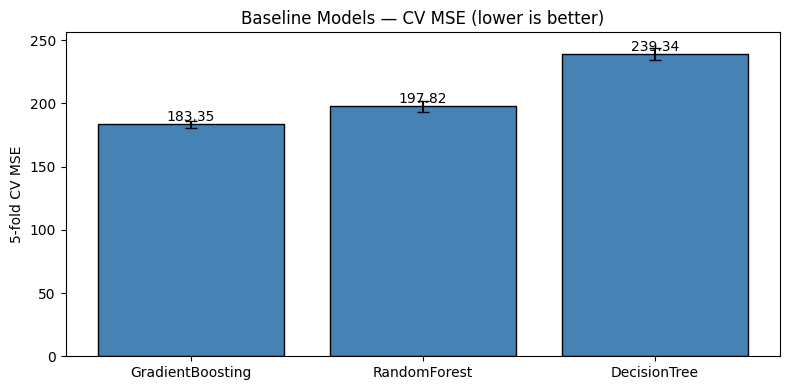

In [32]:
# Quick bar plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['name'], results_df['mse_mean'],
       yerr=results_df['mse_std'], capsize=4, color='steelblue', edgecolor='black')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('Baseline Models — CV MSE (lower is better)')
for i, v in enumerate(results_df['mse_mean']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_cv_bar.png', dpi=120); plt.show()

## 6. Refit Best Model on Full Train → Kaggle Submission

In [33]:
best_name = results_df.iloc[0]['name']
best_model_obj = {'DecisionTree': dt_model,
                  'RandomForest': rf_model,
                  'GradientBoosting': gb_model}[best_name]
print(f'Best baseline: {best_name} (CV MSE = {results_df.iloc[0]["mse_mean"]:.3f})')

best_pipe = Pipeline(steps=[('prep', preprocessor), ('model', best_model_obj)])
best_pipe.fit(X, y)
test_pred = np.clip(best_pipe.predict(X_test), 0, 92)
print('Test predictions shape:', test_pred.shape)
print('First 10 preds:', test_pred[:10].round(2))

Best baseline: GradientBoosting (CV MSE = 183.352)
Test predictions shape: (24318,)
First 10 preds: [ 0.   52.16  5.4  36.2  26.25  1.68  4.49 83.69 74.63 31.38]


In [34]:
# Per-model submissions (refit each on full train) — handy to compare on the public LB.
all_models = {'DecisionTree': dt_model, 'RandomForest': rf_model, 'GradientBoosting': gb_model}
for name, model in all_models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X, y)
    pred = np.clip(pipe.predict(X_test), 0, 92)
    sub = pd.DataFrame({'Property[Q3]_test': test_ids, 'Pred': pred})
    out_path = OUT_DIR / f'submission_baseline_{name}.csv'
    sub.to_csv(out_path, index=False)
    print(f'Saved {out_path.name} | mean={pred.mean():.2f}  zeros={(pred < 0.5).mean()*100:.1f}%')

Saved submission_baseline_DecisionTree.csv | mean=18.18  zeros=32.8%
Saved submission_baseline_RandomForest.csv | mean=18.34  zeros=10.3%
Saved submission_baseline_GradientBoosting.csv | mean=18.20  zeros=19.6%


In [35]:
# Verify submission format
sub = pd.read_csv(OUT_DIR / f'submission_baseline_{best_name}.csv')
print('Header :', list(sub.columns))
print('Rows   :', len(sub))
print('NaNs   :', sub.isna().sum().sum())
print('Range  :', sub['Pred'].min(), '→', sub['Pred'].max())
sub.head()

Header : ['Property[Q3]_test', 'Pred']
Rows   : 24318
NaNs   : 0
Range  : 0.0 → 92.0


,Property[Q3]_test,Pred
0,795,0.000000
1,2515,52.164595
2,2595,5.398003
3,5099,36.200581
4,5107,26.247357


## 7. Permutation Feature Importance (Best Model)
Quick sanity check: do the features we expect to matter (Q2 booking rate, recent window, reviews) actually drive predictions?

In [36]:
# Use a held-out slice (last 20% of rows after shuffling) so we don't pay the
# full CV cost again — this is just a sanity peek.
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.permutation(len(y))
split = int(0.8 * len(y))
tr_idx, va_idx = idx[:split], idx[split:]

best_pipe.fit(X.iloc[tr_idx], y[tr_idx])
perm = permutation_importance(best_pipe, X.iloc[va_idx], y[va_idx],
                              n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE,
                              scoring='neg_mean_squared_error')
imp = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)
imp.head(25)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

,feature,importance,std
27,ReviewsPerMonth,103.131451,2.521099
68,q2_days_R,87.324252,2.625753
32,ResponseRate_missing,39.891591,2.147697
5,NumberofReviews,16.705693,1.013910
144,recent_available_rate,10.893161,1.427162
29,WeeklyDiscount,9.615655,0.755434
143,recent_booking_rate,8.651094,1.213259
140,recent_available,8.373013,1.374930
139,recent_booked,6.217577,1.057546
80,q2_reserved_rate,5.486863,0.486201


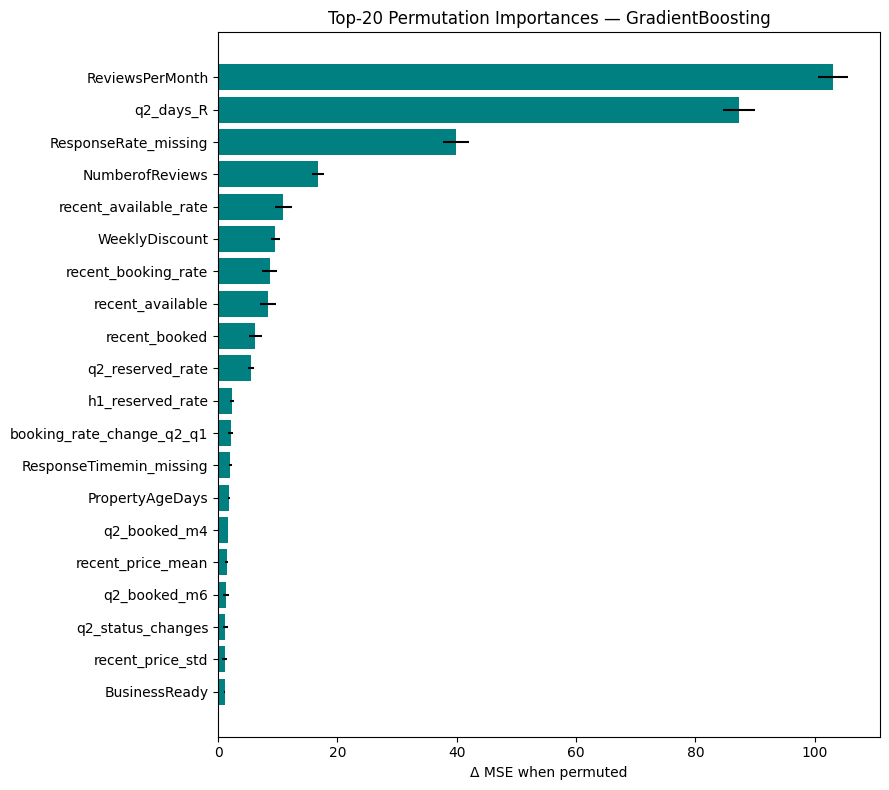

In [37]:
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='teal')
ax.set_title(f'Top-20 Permutation Importances — {best_name}')
ax.set_xlabel('Δ MSE when permuted')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_perm_importance.png', dpi=120); plt.show()

## Summary & Next Step

We now have:
- A reproducible, leakage-free `Pipeline` covering imputation + encoding.
- CV scores for **DecisionTree, RandomForest, GradientBoosting** with consistent splits.
- Out-of-fold predictions saved (for later ensembling).
- Three submission files ready for Kaggle.
- A first read on which engineered features actually move the needle.

### → `04_XGBoost_MLP.ipynb`
Next we'll:
1. Tune **XGBoost** with `RandomizedSearchCV` + early stopping (Module 10-11).
2. Train a **PyTorch MLP** with Adam (Modules 12-13).
3. Compare against baselines and produce a blended final submission.